## Kapitel 6

### 1. Vad är klustring för något? Ge några exempel på tillämpningsområden.

**Klustring** är en metod inom **icke-övervakad inlärning (unsupervised learning)** som automatiskt grupperar datapunkter baserat på hur lika de är varandra. Datapunkter i samma grupp (kluster) liknar varandra, medan datapunkter i olika grupper skiljer sig åt.

**Exempel på tillämpningsområden:**
* **Kundsegmentering:** Gruppera kunder utifrån köpvanor för att skräddarsy marknadsföring.
* **Bildsegmentering:** Gruppera pixlar med liknande färger eller mönster för att identifiera objekt i en bild.
* **Detektering av avvikelser (Anomaly Detection):** Hitta misstänkta kortsändningar eller intrång i datanätverk som inte passar in i något vanligt kluster.
* **Nyhetsgruppering:** Automatiskt samla artiklar som handlar om samma händelse.


### 2. Förklara översiktligt hur K-means fungerar.

**K-means** är en iterativ algoritm för att dela in data i $K$ stycken kluster:

1. **Slumpmässig start (Figur 6.3):**  
   Algoritmen placerar ut $K$ stycken slumpmässiga mittpunkter (centroiders) i datarummet.
2. **Tilldela punkter:**  
   Varje datapunkt kopplas till den centroid som ligger närmast.
3. **Uppdatera centroider (Figur 6.4):**  
   Algoritmen beräknar den nya medelpunkten för alla datapunkter i varje kluster och flyttar centroiden dit.
4. **Upprepa:**  
   Steg 2 och 3 upprepas tills centroidpunkterna inte längre flyttar på sig (algoritmen har konvergerat).


## Resonemangsfrågor

### 3. Hur kan man välja vilket antal kluster ($K$) som ska användas för en K-means modell?

För att hitta det optimala antalet kluster ($K$) använder man följande verktyg:

* **Inertia (Elbow Method):**  
  Inertia mäter hur tätt ihop datapunkterna ligger inom sina kluster (summan av de kvadratiska avstånden till centroiden). 
  * När $K$ ökar minskar alltid inertia. 
  * Man ritar upp en graf över inertia mot $K$ och letar efter en **"armbåge" (elbow)** där minskningen plötsligt planar ut. Det punktvärdet väljs ofta som $K$.
* **Silhouette Score:**  
  Mäter hur väl separerade klustren är från varandra på en skala från $-1$ till $+1$:
  * Ett värde nära $+1$ betyder att punkterna ligger tätt i sitt eget kluster och långt ifrån andra kluster.
  * Man väljer det $K$ som ger det högsta genomsnittliga silhouette score.
* **Silhouette Diagram:**  
  Visar formen och storleken på varje kluster. Det hjälper oss att se om alla kluster har ungefär lika många punkter eller om vissa kluster är felaktigt uppdelade/för små.


### 4. Hur många kluster väljer man i ett Silhouette Diagram (Figur 6.10)? Är det en "exakt vetenskap"?

* **Val av antalet kluster:**  
  Man väljer det antal kluster där alla kluster knivblads-former i diagrammet passerar den streckade linjen (genomsnittligt silhouette score) och där alla kluster har en relativt jämn storlek och bredd.
* **Är det en exakt vetenskap?**  
  **Nej, det är inte en exakt vetenskap.** Det är en kombination av matematiska mått och domänkunskap (affärsnytta). Även om ett visst $K$ har bäst teoretiskt silhouette score kan ett annat $K$ vara mycket mer användbart rent praktiskt för verksamheten.


### 5. Hur tolkar man figur 6.13 på sidan 251?

Figur 6.13 visar silhouette-diagram för fyra olika val av antalet kluster ($k = 3, 4, 5, 6$). Ett silhouette-diagram hjälper oss att utvärdera hur väl separerade och sammanhållna klustren är.


#### Hur man läser diagrammet:

1. **Röd streckad linje:**  
   Representerar det **genomsnittliga silhouette score** för hela modellen vid det givna $k$-värdet. Ju längre till höger linjen ligger, desto bättre är den totala klustringen.

2. **Klustrens form och höjd (knivblad/knivar):**  
   * **Höjden (tjockleken) på knivbladet:** Visar hur många datapunkter som ingår i klustret (antalet observationer).
   * **Bredden (längden till höger):** Visar silhouette-koefficienten för datapunkterna i klustret (hur tätt ihop de ligger och hur långt ifrån andra kluster de befinner sig).

3. **Negativa värden (till vänster om 0.0):**  
   Om delar av knivbladet sträcker sig till vänster om $0.0$ betyder det att dessa punkter troligen har hamnat i fel kluster.


#### Slutsats / Vilket $k$ är bäst?

* **$k = 4$ och $k = 5$ är de bästa valen[cite: 5]:**  
  * I båda dessa fall passerar **alla kluster** den röda streckade linjen, vilket innebär att alla kluster har god kvalitet.
  * Dessutom är knivbladen relativt lika stora/breda, vilket visar på en jämn fördelning av datan.
* **$k = 3$ är sämre:** Kluster 1 är oproportionerligt stort och ojämnt.
* **$k = 6$ är sämre:** Kluster 0 och kluster 5 når inte ens upp till den röda genomsnittslinjen, vilket visar att dessa kluster är svaga och dåligt separerade.

### 7: Koduppgift på Housing-datasetet

### a) Förklaring av koden

Koden utför en k-means-klustring på datasetet `housing.csv` baserat på geografisk plats och inkomst:

1. **Import av bibliotek:** Importerar `matplotlib`, `pandas`, `seaborn` samt klassen `KMeans` från Scikit-Learn.
2. **Laddning & Urval:** Läser in `housing.csv` och väljer ut tre variabler i $X$: `median_income` (medianinkomst), `latitude` (breddgrad) och `longitude` (längdgrad).
3. **K-means-modellering:** Skapar en `KMeans`-modell inställd på 6 kluster (`n_clusters=6`).
4. **Anpassning & Tilldelning:** Tränar modellen och tilldelar varje område ett klusternummer ($0$–$5$) i kolumnen `Cluster` samt omvandlar kolumnen till datatypen `category`.
5. **Visualisering:** Skapar ett spridningsdiagram (relplot) där longitud sätts på x-axeln, latitud på y-axeln och färgen (`hue`) motsvarar klustret. Detta ritar upp en karta över Kalifornien uppdelad i 6 socioekonomiska och geografiska zoner.


### b) Design av marknadsundersökning för respektive kluster

Om jag hade lett en undersökning utifrån dessa 6 geografiska/ekonomiska kluster hade jag designat den enligt följande:

#### Önskad information om klustren:
* **Boendepreferenser:** Föredrar de villor, radhus eller lägenheter? Söker de nytt/nybyggt eller äldre charm?
* **Kommunikationskanaler:** Föredrar de kontakt via e-post, e-postreklam, sociala medier (Instagram/LinkedIn), telefon eller fysisk post?
* **Köpkraft & Livsstil:** Pendlar de till arbete, värdesätter de närhet till skolor, grönområden eller stadsliv?

#### Design av undersökningen:
1. **Stratifierat urval:** Skicka ut enkäter till ett representativt urval av hushåll i de specifika postnummer som ingår i respektive kluster.
2. **Kombinerade metoder:** 
* **Kvantitativ enkät:** Korta digitala enkäter för brett underlag (med incitament, t.ex. lottning av presentkort).
* **Kvalitativa fokusgrupper:** Genomföra djupintervjuer/fokusgrupper med invånare från låg- respektive höginkomstklustren för att förstå deras drivkrafter och behov.

### c) Hur detta är användbart i verkligheten för ett företag

Klustringsresultatet kan ge stor affärsnytta för bland annat fastighetsbolag, banker, handelskedjor och mäklare:

1. **Riktad marknadsföring (Targeted Marketing):** Företag slipper "skjuta brett". Höginkomstkluster utmed kusten kan riktas mot premiumprodukter och lyxrenoveringar, medan kluster i inlandsområden kan få erbjudanden anpassade för prisvärda alternativ.
2. **Etablering av butiker/kontor:** En handelskedja eller bank kan analysera vilket kluster deras målgrupp tillhör och etablera nya kontor eller butiker i områden som tillhör samma kluster.
3. **Prissättningsstrategier:** Fastighetsutvecklare kan anpassa prisläge och standard på nya bostadsprojekt baserat på klustrets inkomstprofil.

### d) Vi har gjort ett enkelt kodexempel, lek gärna runt och fortsätt utveckla
det. Exempelvis kan du undersöka hur många kluster som vore bra att
använda.

### Importerar det vi behöver och läser in datasetet

In [3]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import pandas as pd
import matplotlib.pyplot as plt

housing = pd.read_csv("datasets/housing.csv")

housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### variabler för klustring

In [4]:
# Variabler vi använder för att skapa kluster
cluster_features = [
    'median_income',
    'housing_median_age',
    'total_rooms',
    'total_bedrooms',
    'population',
    'households'
]

X_cluster = housing[cluster_features].dropna()

X_cluster.head()

,median_income,housing_median_age,total_rooms,total_bedrooms,population,households
0,8.3252,41.0,880.0,129.0,322.0,126.0
1,8.3014,21.0,7099.0,1106.0,2401.0,1138.0
2,7.2574,52.0,1467.0,190.0,496.0,177.0
3,5.6431,52.0,1274.0,235.0,558.0,219.0
4,3.8462,52.0,1627.0,280.0,565.0,259.0


### Skalar datan

In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)

print(X_scaled.shape)

(20433, 6)


### Test av olika antal kluster

In [6]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

print(silhouette_scores)

[0.524854424280586, 0.3095430099127248, 0.2820144442101575, 0.2627396215131061, 0.26353898262645975, 0.24070314091526732, 0.2375994082408909, 0.2287169967951041, 0.22930887026843944]


### visualisering

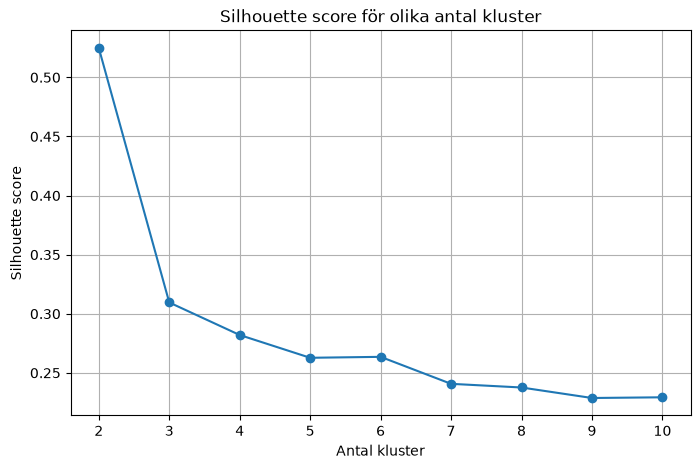

In [7]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker='o'
)

plt.xlabel('Antal kluster')
plt.ylabel('Silhouette score')
plt.title('Silhouette score för olika antal kluster')
plt.xticks(range(2, 11))
plt.grid(True)

plt.show()

### hitta bästa antalet kluster

In [8]:
best_k = range(2, 11)[silhouette_scores.index(max(silhouette_scores))]

print(f"Bästa antal kluster enligt silhouette score: {best_k}")
print(f"Silhouette score: {max(silhouette_scores):.3f}")

Bästa antal kluster enligt silhouette score: 2
Silhouette score: 0.525


### slutgiltig klustring

In [9]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

X_cluster = X_cluster.copy()
X_cluster['cluster'] = clusters

X_cluster.head()

,median_income,housing_median_age,total_rooms,total_bedrooms,population,households,cluster
0,8.3252,41.0,880.0,129.0,322.0,126.0,0
1,8.3014,21.0,7099.0,1106.0,2401.0,1138.0,1
2,7.2574,52.0,1467.0,190.0,496.0,177.0,0
3,5.6431,52.0,1274.0,235.0,558.0,219.0,0
4,3.8462,52.0,1627.0,280.0,565.0,259.0,0


### hur många områden hamnade i varje kluster?

In [10]:
print(X_cluster['cluster'].value_counts().sort_index())

cluster
0    18140
1     2293
Name: count, dtype: int64


### undersök vad klustren betyder

In [11]:
cluster_summary = X_cluster.groupby('cluster')[cluster_features].mean()

cluster_summary.round(2)

,median_income,housing_median_age,total_rooms,total_bedrooms,population,households
cluster,,,,,,
0,3.83,30.04,2090.62,428.35,1153.28,400.29
1,4.17,17.51,6955.01,1404.26,3574.13,1283.76


### visualisering

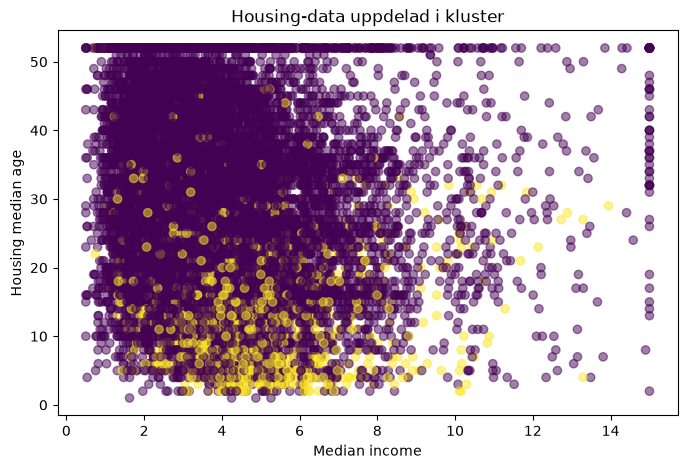

In [12]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X_cluster['median_income'],
    X_cluster['housing_median_age'],
    c=X_cluster['cluster'],
    alpha=0.5
)

plt.xlabel('Median income')
plt.ylabel('Housing median age')
plt.title('Housing-data uppdelad i kluster')

plt.show()

### Analys

Jag utvecklade klusteranalysen genom att testa mellan 2 och 10 kluster. 
För att avgöra vilket antal som passar bäst använde jag silhouette score.

Silhouette score mäter hur väl datapunkterna passar in i sitt eget kluster 
och hur tydligt de skiljer sig från andra kluster. Ett högre värde innebär 
generellt att klustren är bättre separerade.

Utifrån resultatet fick jag att 2 kluster gav högst silhouette score. 
Jag använde därför 2 kluster i den slutliga K-Means-modellen.

Jag undersökte även medelvärdena för variablerna i de olika klustren för att 
se hur områdena skiljer sig åt.

### 9. Genomför en klustringanalys på datasetet som du hittar här: https://www.
kaggle.com/datasets/thebumpkin/1980s-classic-hits-with-spotify-data

### importer och datainläsning

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Läs in datasetet
df = pd.read_csv("datasets/1980sClassics.csv")

print(f"Dataset inläst! Antal rader och kolumner: {df.shape}")
df.head(3)

Dataset inläst! Antal rader och kolumner: (998, 17)


,Track,Artist,Duration,Time_Signature,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Popularity,Year
0,Babe,Styx,3:38,4,0.700,0.582,11,-5.960,0,0.0356,0.0502,0.000000,0.0881,0.785,116.712,96,1980
1,The Rose,Bette Midler,4:04,4,0.264,0.640,8,-6.221,1,0.0442,0.0393,0.000002,0.1510,0.190,84.828,92,1980
2,Cars,Gary Numan,4:08,4,0.338,0.562,9,-7.181,1,0.0290,0.0390,0.000000,0.1070,0.259,149.907,82,1980


### förbered och skala variabeldata

In [18]:
# Välj ut relevanta ljudegenskaper för klustringen
features = [
    'Danceability',
    'Energy',
    'Loudness',
    'Speechiness',
    'Acousticness',
    'Instrumentalness',
    'Liveness',
    'Valence',
    'Tempo',
]

# Standardisera värdena (medelvärde = 0, std = 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

print("Datan är nu skapad och skalad.")

Datan är nu skapad och skalad.


In [19]:
# Kör K-Means med 3 kluster
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Kluster'] = kmeans.fit_predict(X_scaled)

# Namnge klustren baserat på egenskaperna
cluster_names = {
    0: 'Kluster 1: Party & Danspop',
    1: 'Kluster 2: Lugna Ballader',
    2: 'Kluster 3: Snabba Rock/Pop-hits',
}
df['Kluster_Namn'] = df['Kluster'].map(cluster_names)

# Visa antal låtar per kluster
print("Antal låtar per kluster:")
print(df['Kluster_Namn'].value_counts())

Antal låtar per kluster:
Kluster_Namn
Kluster 1: Party & Danspop         427
Kluster 3: Snabba Rock/Pop-hits    310
Kluster 2: Lugna Ballader          261
Name: count, dtype: int64


### Visualisera klustren

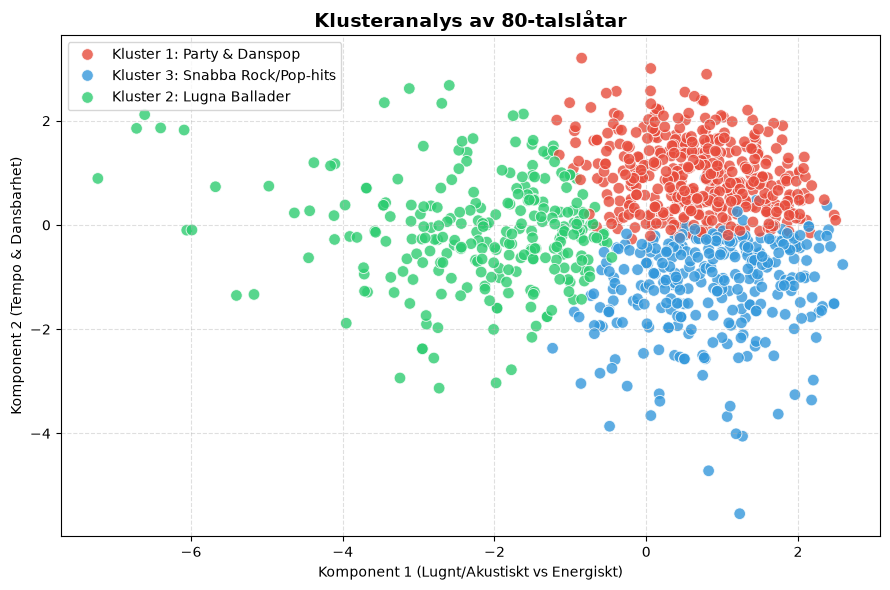

In [20]:
# Minska dimensionerna till 2D med PCA för visualisering
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

# Rita spridningsdiagrammet
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x='PCA1',
    y='PCA2',
    hue='Kluster_Namn',
    palette=['#e74c3c', '#3498db', '#2ecc71'],
    s=70,
    alpha=0.8,
)

plt.title('Klusteranalys av 80-talslåtar', fontsize=14, fontweight='bold')
plt.xlabel('Komponent 1 (Lugnt/Akustiskt vs Energiskt)')
plt.ylabel('Komponent 2 (Tempo & Dansbarhet)')
plt.legend(title='', loc='best')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### Profilöversikt och exempellåtar

In [21]:
# Medelvärden för varje egenskap per kluster
profile = df.groupby('Kluster_Namn')[features].mean().round(2)
print("=== MEDELVÄRDEN PER KLUSTER ===")
display(profile)

# Skriv ut 3 exempellåtar från varje kluster
print("\n=== EXEMPELLÅTAR ===")
for k, name in cluster_names.items():
    print(f"\n{name}:")
    exempel = df[df['Kluster'] == k][['Track', 'Artist', 'Year']].head(3)
    for _, row in exempel.iterrows():
        print(f"  • {row['Track']} – {row['Artist']} ({row['Year']})")

=== MEDELVÄRDEN PER KLUSTER ===


,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo
Kluster_Namn,,,,,,,,,
Kluster 1: Party & Danspop,0.74,0.67,-9.01,0.05,0.15,0.03,0.12,0.78,114.93
Kluster 2: Lugna Ballader,0.53,0.39,-11.92,0.04,0.53,0.08,0.16,0.35,117.56
Kluster 3: Snabba Rock/Pop-hits,0.55,0.78,-6.16,0.08,0.14,0.03,0.28,0.57,131.94



=== EXEMPELLÅTAR ===

Kluster 1: Party & Danspop:
  • Babe – Styx (1980)
  • Magic – Olivia Newton-John (1980)
  • Rock With You – Michael Jackson (1980)

Kluster 2: Lugna Ballader:
  • We Don’t Talk Anymore – Cliff Richard (1980)
  • Lady – Kenny Rogers (1980)
  • All Out Of Love – Air Supply (1980)

Kluster 3: Snabba Rock/Pop-hits:
  • The Rose – Bette Midler (1980)
  • Cars – Gary Numan (1980)
  • Desire – Andy Gibb (1980)


## Slutsats: Klusteranalys av 80-talsklassiker

Analysen visar att de 998 låtarna i datasetet naturligt delar in sig i **3 huvudsakliga ljud- och stämningsgrupper**:

* **Kluster 1: Party & Danspop (43 %)** – Högst dansbarhet (*0.74*) och mest positiva ton (*Valence 0.78*).
* **Kluster 2: Lugna Ballader (26 %)** – Lägst energi (*0.39*) och volym (*-11.9 dB*), men hög akustisk känsla (*0.53*).
* **Kluster 3: Snabba Rock/Pop-hits (31 %)** – Högst energi (*0.78*), högst volym (*-6.16 dB*) och snabbast tempo (*132 BPM*).

### Affärsnytta
* **Stämningsbaserade spellistor:** Gör det möjligt för streamingtjänster att automatiskt skapa temalistor (t.ex. *"80s Workout"* vs. *"80s Slow Ballads"*).
* **Bättre rekommendationer:** Användare kan få rekommendationer baserade på låtens faktiska karaktär och tempo, snarare än bara genre eller artist.